In [27]:
from lib.readwav import readwav
from lib.functions import get_f0_from_peaks, extract_harmonics, get_average_spectrum
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [28]:
%matplotlib widget
plt.close('all')

In [29]:
note_data = readwav('Data_organ/note_2.wav')
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]

(382223, 2)


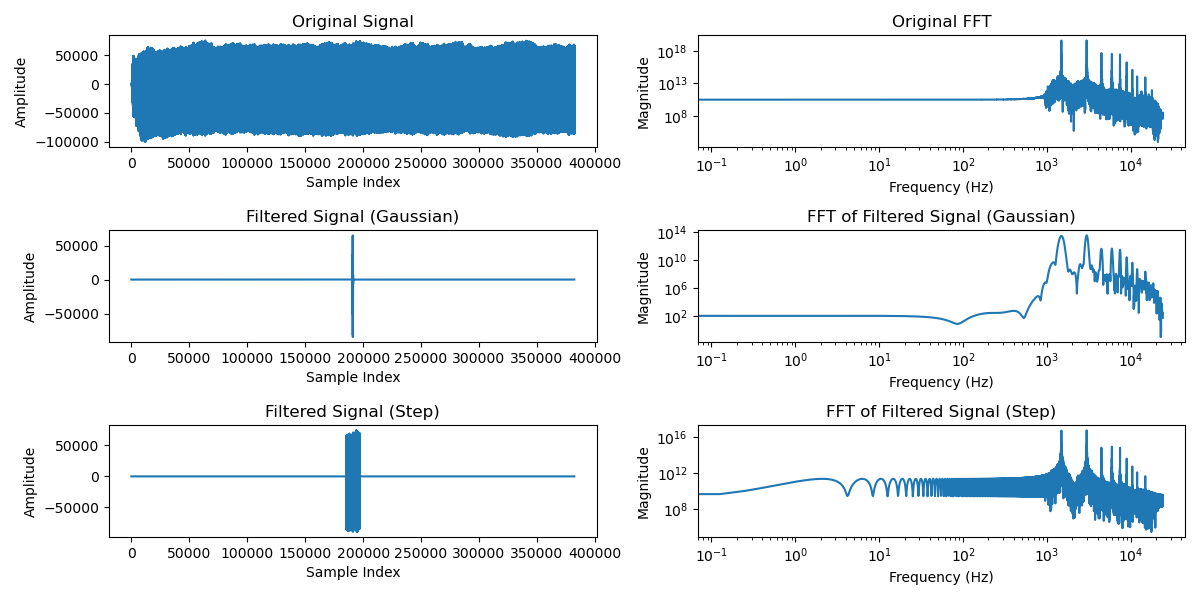

In [30]:
data = channel1

N = len(data)
n = np.arange(N)

window_size_gauss_fine = 200#round(N*0.03)
window_size_gauss_coarse = round(N*0.6)
window_size_step = round(N*0.03)

gaussian_window_fine = np.exp(-0.5 * ((n - N/2) / (window_size_gauss_fine/2))**2)
step_window = np.zeros(N)
step_window[N // 2 - window_size_step // 2:N // 2 + window_size_step//2] = 1

filtered_data_gauss = gaussian_window_fine * data
filtered_data_step = step_window * data

fft_data = sp.fft.rfft(data)
frequencies = sp.fft.rfftfreq(N, d=1/rate)

fft_filtered_data_gauss = sp.fft.rfft(filtered_data_gauss)
frequencies_filtered_gauss = sp.fft.rfftfreq(N, d=1/rate)

fft_filtered_data_step = sp.fft.rfft(filtered_data_step)
frequencies_filtered_step = sp.fft.rfftfreq(N, d=1/rate)

plt.figure(figsize=(12, 6))

plt.subplot(3,2,1)

plt.plot(n, data, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3,2,2)

plt.plot(frequencies, np.abs(fft_data)**2, label='Original fft')
plt.xscale('log')
plt.yscale('log')
plt.title('Original FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.subplot(3,2,3)
plt.plot(n, filtered_data_gauss, label='Filtered Signal (Gaussian)')
plt.title('Filtered Signal (Gaussian)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3,2,4)
plt.plot(frequencies_filtered_gauss, np.abs(fft_filtered_data_gauss)**2, label='FFT of Filtered Signal (Gaussian)')
plt.xscale('log')
plt.yscale('log')
plt.title('FFT of Filtered Signal (Gaussian)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.subplot(3,2,5)
plt.plot(n, filtered_data_step, label='Filtered Signal (Step)')
plt.title('Filtered Signal (Step)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3,2,6)
plt.plot(frequencies_filtered_step, np.abs(fft_filtered_data_step)**2, label='FFT of Filtered Signal (Step)')
plt.xscale('log')
plt.yscale('log')
plt.title('FFT of Filtered Signal (Step)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')


plt.tight_layout()
plt.show()


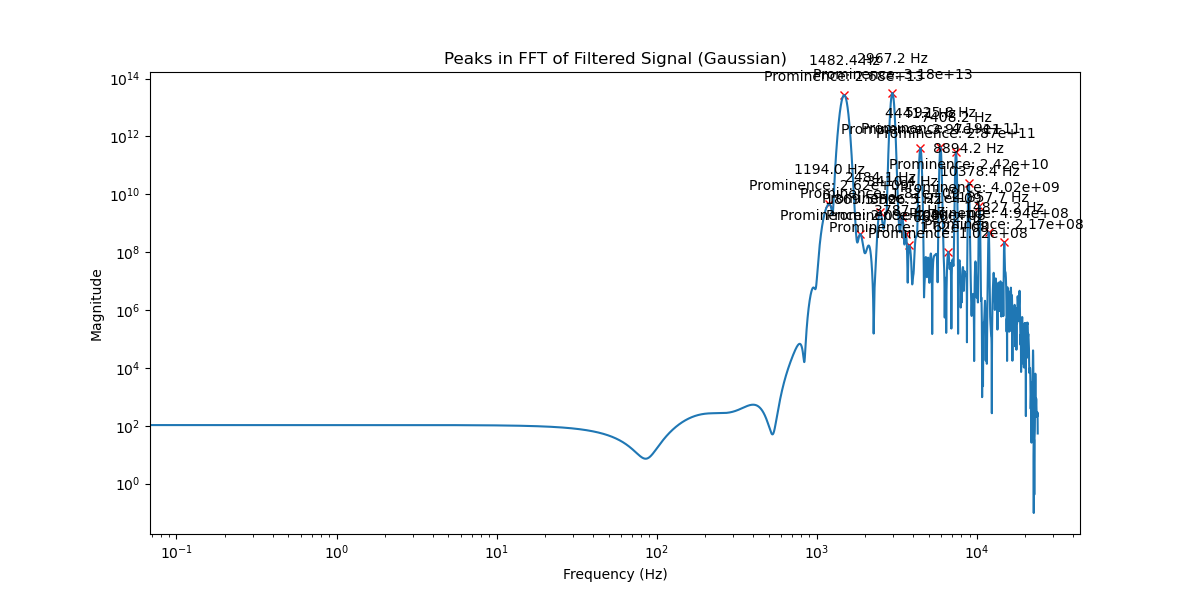

In [31]:
plt.figure(figsize=(12, 6))

peaks, _ = sp.signal.find_peaks(np.abs(fft_filtered_data_gauss)**2, prominence=1e8)
prominences = sp.signal.peak_prominences(np.abs(fft_filtered_data_gauss)**2, peaks)[0]

plt.plot(frequencies[peaks], np.abs(fft_filtered_data_gauss)[peaks]**2, 'rx', label='Peaks')

for i, (peak, prominence) in enumerate(zip(peaks, prominences)):
    plt.annotate(f'{frequencies[peak]:.1f} Hz\nProminence: {prominence:.2e}', 
                 (frequencies[peak], np.abs(fft_filtered_data_gauss)[peak]**2), 
                 textcoords="offset points", xytext=(0,10), ha='center')


plt.plot(frequencies, np.abs(fft_filtered_data_gauss)**2, label='Original fft')

plt.yscale('log')
plt.xscale('log')
plt.title('Peaks in FFT of Filtered Signal (Gaussian)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

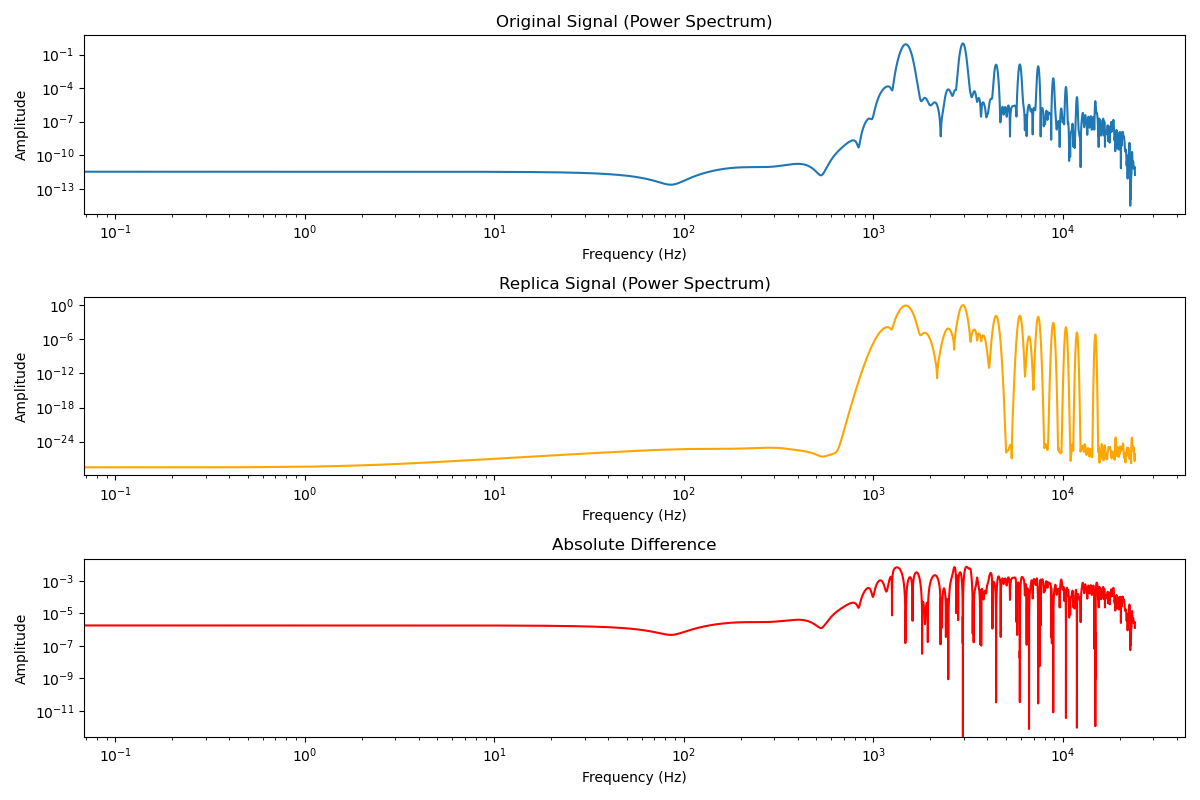

In [32]:
peaks_frequencies = frequencies[peaks]
peaks_amplitudes = np.abs(fft_filtered_data_gauss)[peaks]
peaks_phases = np.angle(fft_filtered_data_gauss)[peaks]

signal_replica = np.zeros(N)

for freq, amp, phase in zip(peaks_frequencies, peaks_amplitudes, peaks_phases):

    actual_f = freq / rate
    signal_replica += amp * np.cos(2 * np.pi * actual_f * n + phase)


data_normalized = data / np.max(np.abs(data))
signal_replica_normalized = signal_replica / np.max(np.abs(signal_replica))


data_normalized *= gaussian_window_fine
signal_replica_normalized *= gaussian_window_fine

fft_original = sp.fft.rfft(data_normalized)
fft_replica = sp.fft.rfft(signal_replica_normalized)

fft_original_abs = np.abs(fft_original) / np.max(np.abs(fft_original))
fft_replica_abs = np.abs(fft_replica) / np.max(np.abs(fft_replica))

fft_difference = fft_original_abs - fft_replica_abs
frequencies_axis = sp.fft.rfftfreq(N, d=1/rate)

plt.figure(figsize=(12, 8))

plt.subplot(3,1,1)
plt.plot(frequencies_axis, fft_original_abs**2, label='Original')
plt.title('Original Signal (Power Spectrum)')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Amplitude')
plt.xlabel('Frequency (Hz)')

plt.subplot(3,1,2)
plt.plot(frequencies_axis, fft_replica_abs**2, label='Reconstructed', color='orange')
plt.title('Replica Signal (Power Spectrum)')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Amplitude')
plt.xlabel('Frequency (Hz)')

plt.subplot(3,1,3)

plt.plot(frequencies_axis, np.abs(fft_difference), label='Residual Error', color='red')
plt.title('Absolute Difference')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Amplitude')
plt.xlabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

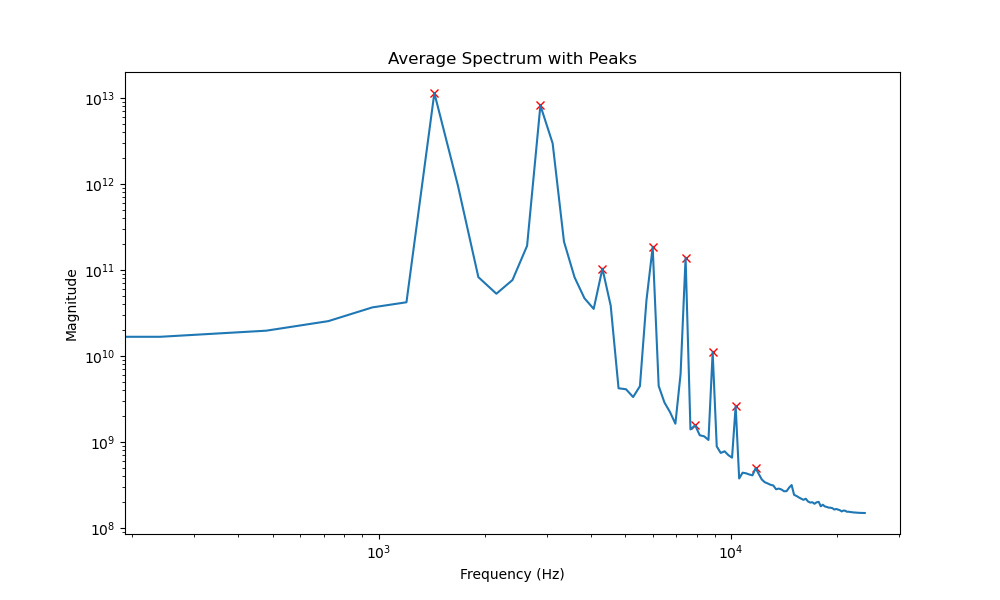

f0 stimata dallo spettro medio: 1440.00 Hz
Features:
[1.         0.84685428 0.09530267 0.0622034  0.0232563  0.00961769
 0.00759055 0.00598997]


In [35]:
freqs, avg_magnitude = get_average_spectrum(data, rate, window_size_gauss_fine, window_size_step)

peaks_avg, _ = sp.signal.find_peaks(np.abs(avg_magnitude)**2, prominence=1e8)
prominences = sp.signal.peak_prominences(np.abs(avg_magnitude)**2, peaks_avg)[0]

plt.figure(figsize=(10, 6))

plt.plot(freqs[peaks_avg], np.abs(avg_magnitude)[peaks_avg]**2, 'rx', label='Peaks')
plt.plot(freqs, np.abs(avg_magnitude)**2, label='Average Spectrum')
plt.yscale('log')
plt.xscale('log')
plt.title('Average Spectrum with Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

f0_stimata = get_f0_from_peaks(freqs[peaks_avg])
print(f"f0 stimata dallo spettro medio: {f0_stimata:.2f} Hz")

features = extract_harmonics(freqs, avg_magnitude, f0_stimata, 8)

print("Features:")
print(features)

In [36]:
from IPython.display import Audio


display(Audio(signal_replica_normalized, rate=rate))
display(Audio(10 * data, rate=rate))